In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv(r"glass.csv")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [4]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [5]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [6]:
df.shape

(214, 10)

# BUSINESS PROBLEM

Write this in assignment documentation.

Business Objective

The glass manufacturing company wants to automate the classification of glass types based on chemical composition to reduce manual effort and improve accuracy.

Constraints
Accurate classification is required
Misclassification may affect manufacturing quality
Model should work efficiently on new glass samples

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df = df.drop_duplicates()

we build histogram for univariate analysis

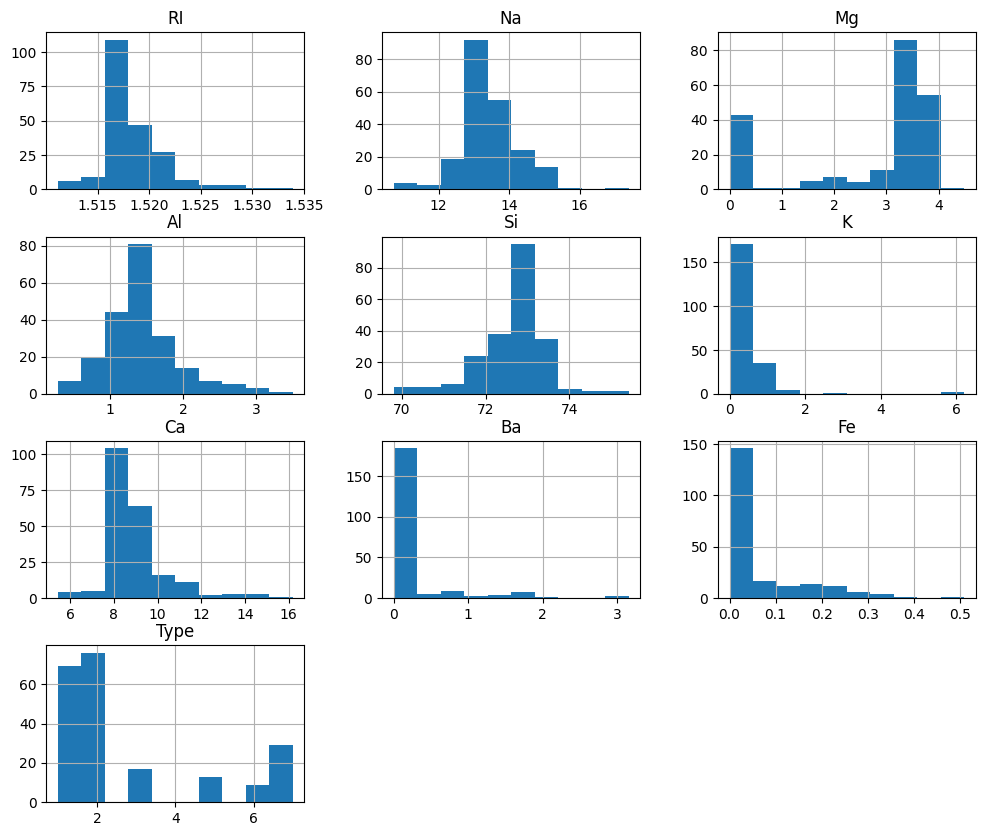

In [9]:
df.hist(figsize=(12,10))
plt.show()

for outlier detection we use box plot

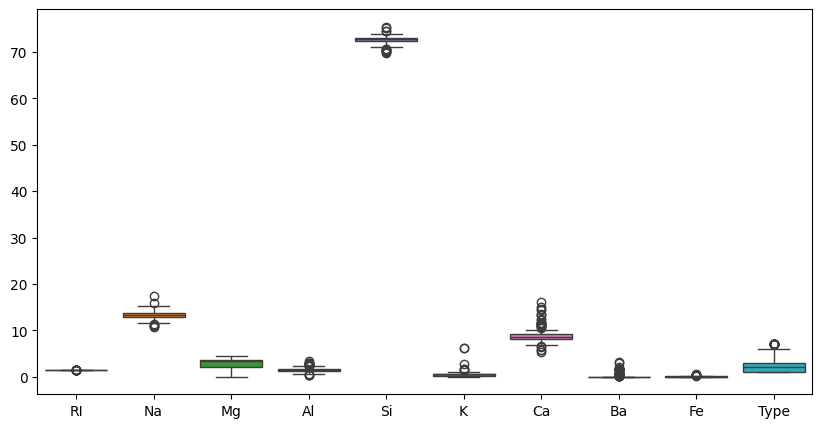

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.show()

To see the correlation between features we need to build heatmap and this will help us to select our x and y for predicting the model. Which feature are highly corerlated and effect our target column and also this helps understand feature relationships.

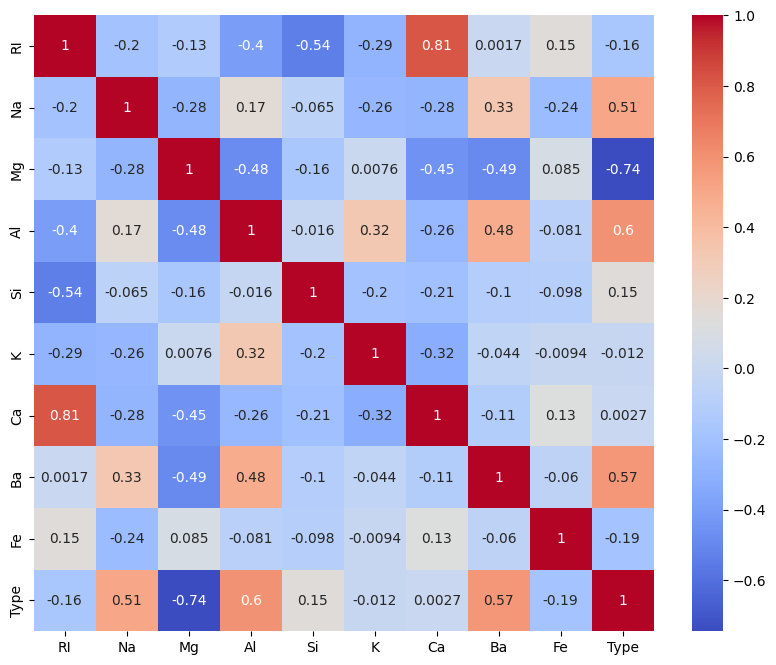

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# DEFINE X and y

X = Input Features

y = Target Variable

In [12]:
X = df.drop("Type", axis=1)
y = df["Type"]

KNN uses distance calculation so for that we needc to scale our data so we use feature scaling (StandardScaler)

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# TRAIN TEST SPLIT

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

BUILD FIRST KNN MODEL where we put the value of k is 3

In [15]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Predict the value 

In [16]:
y_pred = knn.predict(X_test)

MODEL EVALUATION

In [17]:
accuracy_score(y_test, y_pred)

0.6744186046511628

Classification Report

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.56      0.90      0.69        10
           2       0.62      0.67      0.65        15
           3       0.00      0.00      0.00         3
           5       0.50      0.33      0.40         3
           6       1.00      0.67      0.80         3
           7       1.00      0.78      0.88         9

    accuracy                           0.67        43
   macro avg       0.61      0.56      0.57        43
weighted avg       0.66      0.67      0.65        43



c:\Users\rajpu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rajpu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rajpu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Confusion Matrix

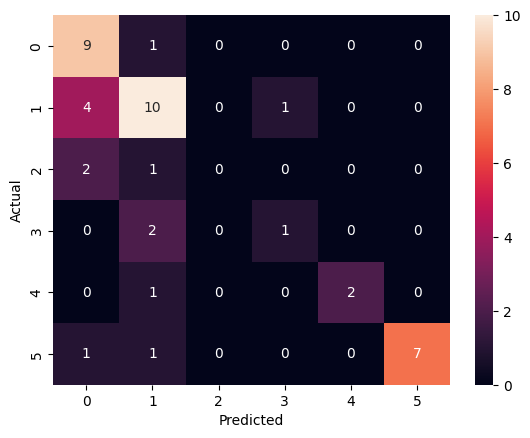

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

for find the best k value we need to give different diffeen k value so for that we use a for loop with range funtion from 1 to 21

In [20]:
accuracy = []

for i in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=i)

    scores = cross_val_score(
        knn,
        X_scaled,
        y,
        cv=5
    )

    accuracy.append(scores.mean())

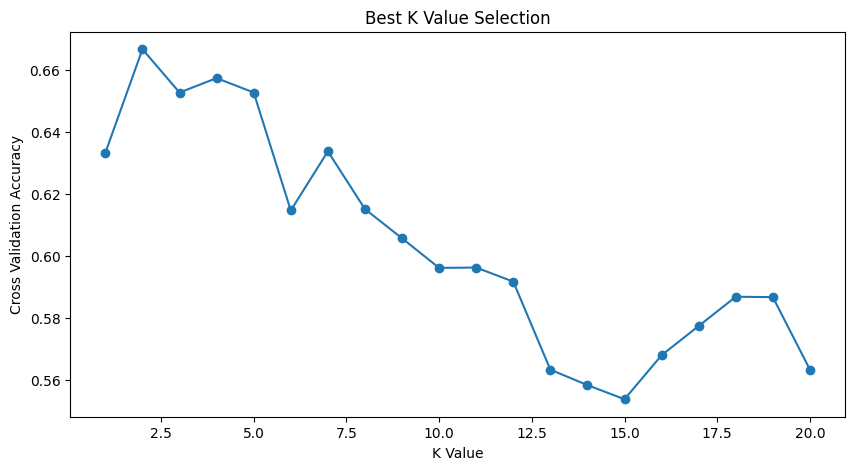

In [21]:
plt.figure(figsize=(10,5))

plt.plot(range(1,21), accuracy, marker='o')

plt.xlabel("K Value")
plt.ylabel("Cross Validation Accuracy")
plt.title("Best K Value Selection")

plt.show()

In [22]:
best_k = np.argmax(accuracy) + 1

print("Best K Value:", best_k)

Best K Value: 2


Now we find the best k let create a mnodel with that 

In [23]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train, y_train)

final_pred = final_knn.predict(X_test)

Final Accuracy

In [24]:
print("Accuracy:",
      accuracy_score(y_test, final_pred))

Accuracy: 0.627906976744186


CROSS VALIDATION

In [25]:
cv_scores = cross_val_score(
    final_knn,
    X_scaled,
    y,
    cv=5
)

print(cv_scores)

print("Average CV Score:", cv_scores.mean())

[0.55813953 0.76744186 0.6744186  0.5952381  0.73809524]
Average CV Score: 0.6666666666666667


# Model Output Explanation

KNN model classifies glass types using nearest neighbors.

Feature scaling improved distance calculation performance.

Cross-validation helped select optimal K value.

Final model achieved good classification accuracy.